In [2]:
pip install sktime

  Using cached sktime-0.36.1-py3-none-any.whl.metadata (34 kB)
  Using cached scikit_base-0.12.2-py3-none-any.whl.metadata (8.8 kB)
Using cached sktime-0.36.1-py3-none-any.whl (37.0 MB)
Using cached scikit_base-0.12.2-py3-none-any.whl (142 kB)
Note: you may need to restart the kernel to use updated packages.


In [36]:
import pandas as pd
import numpy as np
from decimal import Decimal, ROUND_HALF_UP
from xgboost import XGBClassifier
import xgboost as xgb
from lightgbm import LGBMClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [4]:
case_df = pd.read_csv('s3://ads508-s3/time_series_covid19_confirmed_US.csv')
case_df.head()

,UID,iso2,iso3,code3,FIPS,Admin2,Province_State,Country_Region,Lat,Long_,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,84001001,US,USA,840,1001.0,Autauga,Alabama,US,32.539527,-86.644082,...,19732,19759,19759,19759,19759,19759,19759,19759,19790,19790
1,84001003,US,USA,840,1003.0,Baldwin,Alabama,US,30.727750,-87.722071,...,69641,69767,69767,69767,69767,69767,69767,69767,69860,69860
2,84001005,US,USA,840,1005.0,Barbour,Alabama,US,31.868263,-85.387129,...,7451,7474,7474,7474,7474,7474,7474,7474,7485,7485
3,84001007,US,USA,840,1007.0,Bibb,Alabama,US,32.996421,-87.125115,...,8067,8087,8087,8087,8087,8087,8087,8087,8091,8091
4,84001009,US,USA,840,1009.0,Blount,Alabama,US,33.982109,-86.567906,...,18616,18673,18673,18673,18673,18673,18673,18673,18704,18704


In [5]:
death_df = pd.read_csv('s3://ads508-s3/time_series_covid19_deaths_US.csv')
death_df.head()

,UID,iso2,iso3,code3,FIPS,Admin2,Province_State,Country_Region,Lat,Long_,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,84001001,US,USA,840,1001.0,Autauga,Alabama,US,32.539527,-86.644082,...,230,232,232,232,232,232,232,232,232,232
1,84001003,US,USA,840,1003.0,Baldwin,Alabama,US,30.727750,-87.722071,...,724,726,726,726,726,726,726,726,727,727
2,84001005,US,USA,840,1005.0,Barbour,Alabama,US,31.868263,-85.387129,...,103,103,103,103,103,103,103,103,103,103
3,84001007,US,USA,840,1007.0,Bibb,Alabama,US,32.996421,-87.125115,...,109,109,109,109,109,109,109,109,109,109
4,84001009,US,USA,840,1009.0,Blount,Alabama,US,33.982109,-86.567906,...,261,261,261,261,261,261,261,261,261,261


In [6]:
case_df.columns

Index(['UID', 'iso2', 'iso3', 'code3', 'FIPS', 'Admin2', 'Province_State',
       'Country_Region', 'Lat', 'Long_',
       ...
       '2/28/23', '3/1/23', '3/2/23', '3/3/23', '3/4/23', '3/5/23', '3/6/23',
       '3/7/23', '3/8/23', '3/9/23'],
      dtype='object', length=1154)

In [7]:
print(case_df.shape)
print(death_df.shape)

(3342, 1154)
(3342, 1155)


In [8]:
case_df = case_df.drop(
    columns=['UID', 'iso2', 'iso3', 'code3', 'FIPS', 'Country_Region', 'Combined_Key'],
    errors='ignore'
)

# Drop rows where 'Admin2' is missing
case_df = case_df.dropna(subset=['Admin2'])

# Reshape the dataframe from wide to long
case_df = pd.melt(
    case_df,
    id_vars=['Admin2', 'Province_State', 'Lat', 'Long_'],
    var_name='Date',
    value_name='Deaths'  # Use different name to avoid conflict
)

# Convert 'Date' column with explicit format
case_df['Date'] = pd.to_datetime(case_df['Date'], format='%m/%d/%y')

# Optimize memory usage
case_df['Deaths'] = pd.to_numeric(case_df['Deaths'], downcast='integer')
case_df['Lat'] = np.round(case_df['Lat'], 3)
case_df['Long_'] = np.round(case_df['Long_'], 3)
case_df['Admin2'] = case_df['Admin2'].astype('category')
case_df['Province_State'] = case_df['Province_State'].astype('category')

# Resample weekly death data
case_df.set_index('Date', inplace=True)
case_resample = case_df.groupby(
    ['Admin2', 'Lat', 'Long_', 'Province_State'],
    observed=False
).resample('W')['Deaths'].sum().reset_index()

# Final cleanup
case_resample.reset_index(drop=True, inplace=True)

In [9]:
death_df = death_df.drop(
    columns=['UID', 'iso2', 'iso3', 'code3', 'FIPS', 'Country_Region', 'Combined_Key'],
    errors='ignore'
)

# Drop rows where 'Admin2' is missing
death_df = death_df.dropna(subset=['Admin2'])

# Reshape the DataFrame from wide to long
death_df = pd.melt(
    death_df,
    id_vars=['Admin2', 'Province_State', 'Lat', 'Long_', 'Population'],
    var_name='Date',
    value_name='Confirmed'
)

# Convert 'Date' column with explicit format
death_df['Date'] = pd.to_datetime(death_df['Date'], format='%m/%d/%y')

# Optimize memory usage
death_df['Confirmed'] = pd.to_numeric(death_df['Confirmed'], downcast='integer')
death_df['Population'] = pd.to_numeric(death_df['Population'], downcast='integer')
death_df['Lat'] = np.round(death_df['Lat'], 3)
death_df['Long_'] = np.round(death_df['Long_'], 3)
death_df['Admin2'] = death_df['Admin2'].astype('category')
death_df['Province_State'] = death_df['Province_State'].astype('category')

# Resample weekly confirmed data
death_df.set_index('Date', inplace=True)
death_resample = death_df.groupby(
    ['Admin2', 'Lat', 'Long_', 'Province_State', 'Population'],
    observed=False
).resample('W')['Confirmed'].sum().reset_index()

# Final cleanup
death_resample.reset_index(drop=True, inplace=True)

In [10]:
death_staging = death_resample[['Date', 'Admin2', 'Lat', 'Long_', 'Province_State', 'Population', 'Confirmed']]

# Merge on full key set to avoid many-to-many explosion
base_df = pd.merge(
    case_resample,
    death_staging,
    on=['Date', 'Admin2', 'Lat', 'Long_', 'Province_State'],
    how='left'
)

base_df.head()

,Admin2,Lat,Long_,Province_State,Date,Deaths,Population,Confirmed
0,Abbeville,34.223,-82.462,South Carolina,2020-01-26,0,24527,0
1,Abbeville,34.223,-82.462,South Carolina,2020-02-02,0,24527,0
2,Abbeville,34.223,-82.462,South Carolina,2020-02-09,0,24527,0
3,Abbeville,34.223,-82.462,South Carolina,2020-02-16,0,24527,0
4,Abbeville,34.223,-82.462,South Carolina,2020-02-23,0,24527,0


In [11]:
base_df.shape

(547104, 8)

In [12]:
print(base_df['Date'].min())
print(base_df['Date'].max())

2020-01-26 00:00:00
2023-03-12 00:00:00


In [13]:
"""The following are the top 10 states with the most covid deaths between 01-26-2020 and 03-12-2023... The numbers are not adding up properly need to look more into this"""
(
    base_df
    .groupby('Province_State', observed=False)['Confirmed']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

Province_State
California      65490302
Texas           61302166
New York        58121236
Florida         51475342
Pennsylvania    31912144
Illinois        28240376
New Jersey      28101090
Georgia         26228841
Ohio            26072614
Michigan        25546398
Name: Confirmed, dtype: int32

In [16]:
HOTSPOT_THRESHOLD = 20

base_df['is_hotspot'] = (base_df['Deaths'] > HOTSPOT_THRESHOLD).astype(int)
base_df.head()

,Admin2,Lat,Long_,Province_State,Date,Deaths,Population,Confirmed,is_hotspot
0,Abbeville,34.223,-82.462,South Carolina,2020-01-26,0,24527,0,0
1,Abbeville,34.223,-82.462,South Carolina,2020-02-02,0,24527,0,0
2,Abbeville,34.223,-82.462,South Carolina,2020-02-09,0,24527,0,0
3,Abbeville,34.223,-82.462,South Carolina,2020-02-16,0,24527,0,0
4,Abbeville,34.223,-82.462,South Carolina,2020-02-23,0,24527,0,0


In [17]:
base_df['is_hotspot'].value_counts(normalize=True)

is_hotspot
1    0.895857
0    0.104143
Name: proportion, dtype: float64

In [20]:
base_df = base_df.sort_values(['Admin2', 'Date'])

for lag in [1, 2, 3]:
    base_df[f'lag_{lag}_deaths'] = (
        base_df
        .groupby('Admin2')['Deaths']
        .shift(lag)
    )
    base_df[f'lag_{lag}_confirmed'] = (
        base_df
        .groupby('Admin2')['Confirmed']
        .shift(lag)
    )


In [21]:
base_df['roll_3w_avg_deaths'] = (
    base_df
    .groupby('Admin2')['Deaths']
    .rolling(window=3)
    .mean()
    .reset_index(level=0, drop=True)
)

In [23]:
base_df['weekofyear'] = base_df['Date'].dt.isocalendar().week
base_df['month'] = base_df['Date'].dt.month
base_df['year'] = base_df['Date'].dt.year

In [24]:
base_df.head()

,Admin2,Lat,Long_,Province_State,Date,Deaths,Population,Confirmed,is_hotspot,lag_1_deaths,lag_1_confirmed,lag_2_deaths,lag_2_confirmed,lag_3_deaths,lag_3_confirmed,roll_3w_avg_deaths,weekofyear,month,year
0,Abbeville,34.223,-82.462,South Carolina,2020-01-26,0,24527,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,1,2020
1,Abbeville,34.223,-82.462,South Carolina,2020-02-02,0,24527,0,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,5,2,2020
2,Abbeville,34.223,-82.462,South Carolina,2020-02-09,0,24527,0,0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,6,2,2020
3,Abbeville,34.223,-82.462,South Carolina,2020-02-16,0,24527,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7,2,2020
4,Abbeville,34.223,-82.462,South Carolina,2020-02-23,0,24527,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8,2,2020


In [39]:
df = base_df.dropna()

feature_cols = [
    'Confirmed', 'Population', 'Lat', 'Long_',
    'lag_1_deaths', 'lag_2_deaths', 'lag_1_confirmed', 'lag_2_confirmed',
    'weekofyear', 'month', 'year'
]

X = df[feature_cols]
y = df['is_hotspot']

In [40]:
cutoff_date = df['Date'].max() - pd.Timedelta(weeks=4)

X_train = X[df['Date'] < cutoff_date]
y_train = y[df['Date'] < cutoff_date]

X_test = X[df['Date'] >= cutoff_date]
y_test = y[df['Date'] >= cutoff_date]


Training XGBoost...

--- XGBoost Evaluation ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       481
           1       1.00      1.00      1.00     16199

    accuracy                           1.00     16680
   macro avg       0.99      0.99      0.99     16680
weighted avg       1.00      1.00      1.00     16680



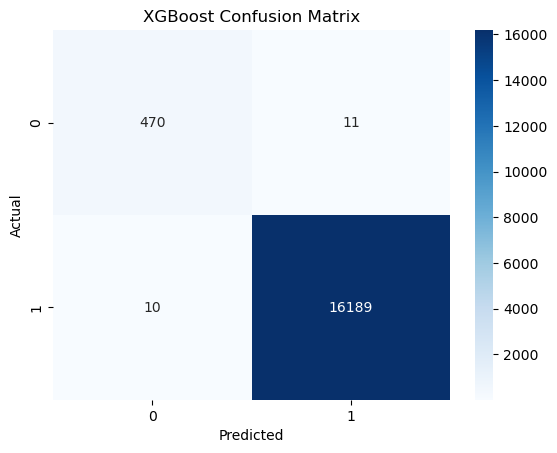

ROC AUC: 0.9998


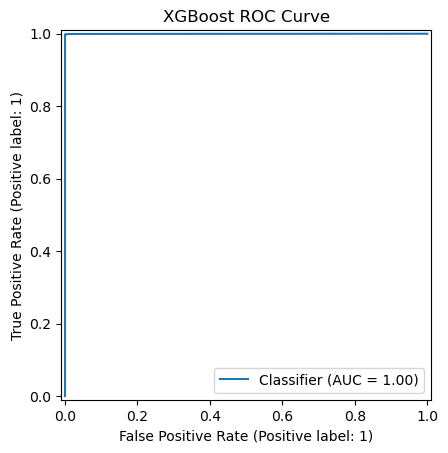

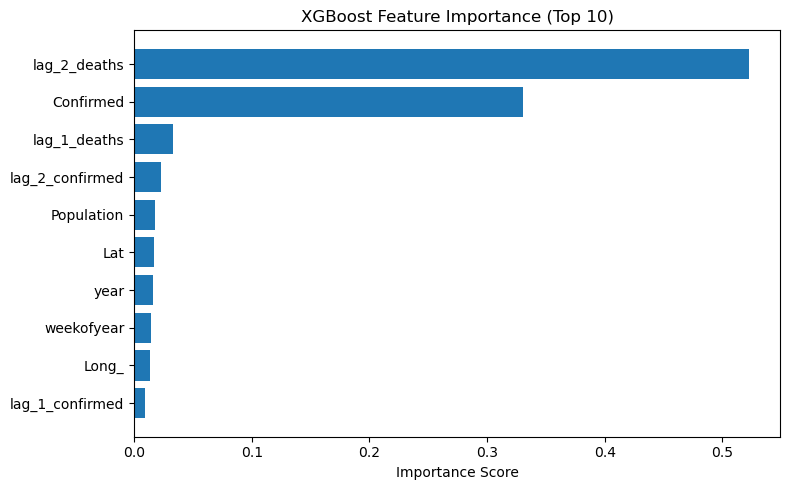


Training LightGBM...
[LightGBM] [Info] Number of positive: 473928, number of negative: 50556
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017868 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2112
[LightGBM] [Info] Number of data points in the train set: 524484, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903608 -> initscore=2.237974
[LightGBM] [Info] Start training from score 2.237974

--- LightGBM Evaluation ---
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       481
           1       1.00      1.00      1.00     16199

    accuracy                           1.00     16680
   macro avg       0.97      0.98      0.98     16680
weighted avg       1.00      1.00      1.00     16680



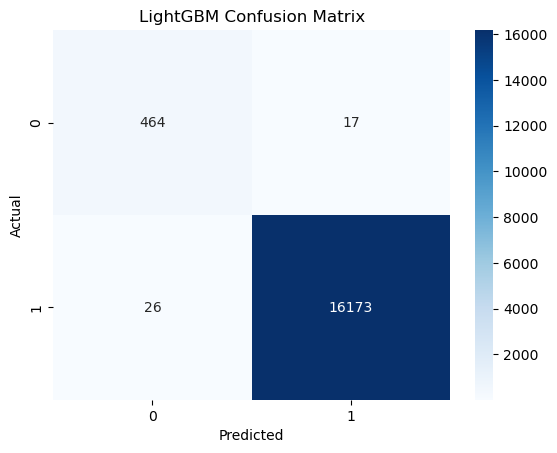

ROC AUC: 0.9997


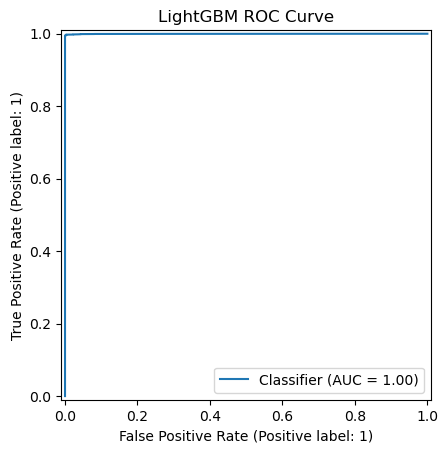

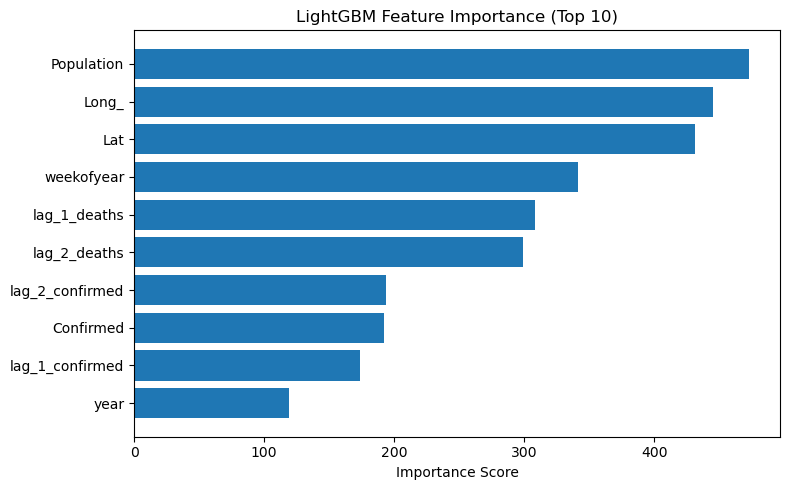


Training DecisionTree...

--- DecisionTree Evaluation ---
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       481
           1       1.00      1.00      1.00     16199

    accuracy                           1.00     16680
   macro avg       0.98      0.98      0.98     16680
weighted avg       1.00      1.00      1.00     16680



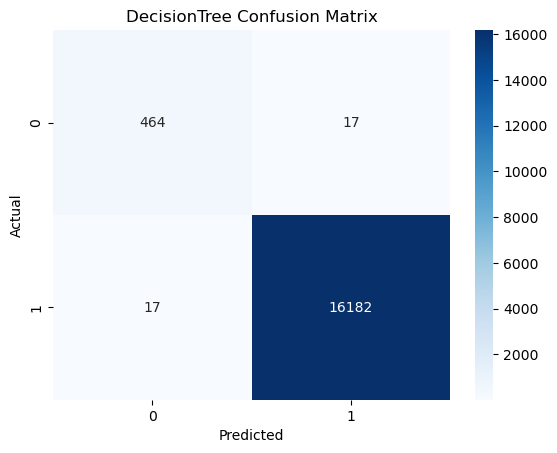

ROC AUC: 0.9817


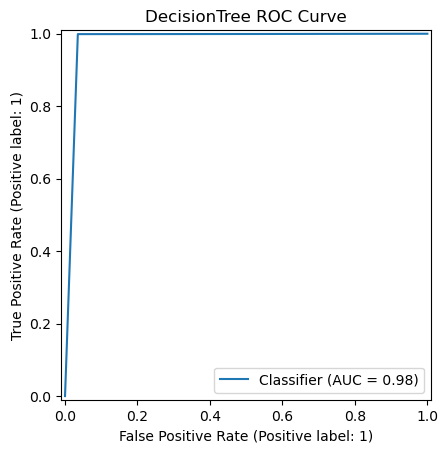

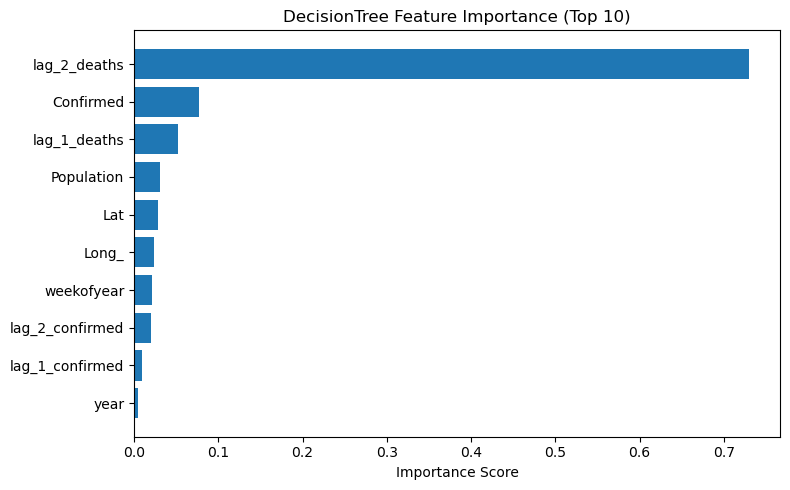


Training Bagging...

--- Bagging Evaluation ---
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       481
           1       1.00      1.00      1.00     16199

    accuracy                           1.00     16680
   macro avg       0.98      0.98      0.98     16680
weighted avg       1.00      1.00      1.00     16680



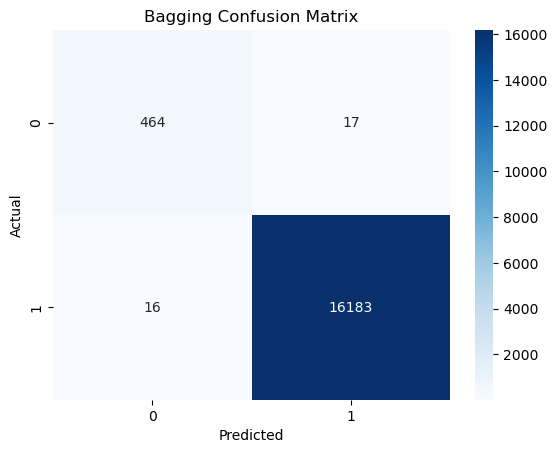

ROC AUC: 0.9988


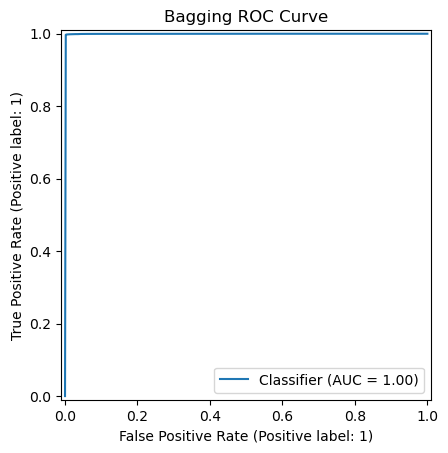

In [42]:
models = {
    'XGBoost': XGBClassifier(
        tree_method='hist',          # CPU-optimized tree method
        use_label_encoder=False,
        eval_metric='logloss'
    ),
    'LightGBM': LGBMClassifier(     # CPU is default
        boosting_type='gbdt'
    ),
    'DecisionTree': DecisionTreeClassifier(),
    'Bagging': BaggingClassifier(
        estimator=DecisionTreeClassifier()
    )
}




def train_model(model, X_train, y_train):
    model.fit(X_train, y_train)
    return model

def evaluate_model(name, model, X_test, y_test):
    print(f"\n--- {name} Evaluation ---")
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    if y_prob is not None:
        roc_auc = roc_auc_score(y_test, y_prob)
        print(f"ROC AUC: {roc_auc:.4f}")
        RocCurveDisplay.from_predictions(y_test, y_prob)
        plt.title(f"{name} ROC Curve")
        plt.show()

def plot_feature_importance(model, feature_names, name):
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        sorted_idx = importances.argsort()[::-1]
        top_n = min(10, len(importances))
        plt.figure(figsize=(8, 5))
        plt.barh(
            [feature_names[i] for i in sorted_idx[:top_n]][::-1],
            importances[sorted_idx[:top_n]][::-1]
        )
        plt.title(f"{name} Feature Importance (Top {top_n})")
        plt.xlabel("Importance Score")
        plt.tight_layout()
        plt.show()

trained_models = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    trained = train_model(model, X_train, y_train)
    trained_models[name] = trained
    evaluate_model(name, trained, X_test, y_test)
    plot_feature_importance(trained, X_train.columns, name)